In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("car_evaluation.csv")

In [3]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
df.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')

In [5]:
columns = {
    'vhigh': 'buying price',
    'vhigh.1': 'maintenance cost',
    '2' : 'number of doors',
    '2.1' : 'number of persons',
    'small' : 'lug_boot',
    'low' : 'safety',
    'unacc' : 'class'
}

In [6]:
# col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
# df.columns = col_names

In [7]:
df.rename(columns=columns,inplace=True)

In [8]:
df.head()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying price       1727 non-null   object
 1   maintenance cost   1727 non-null   object
 2   number of doors    1727 non-null   object
 3   number of persons  1727 non-null   object
 4   lug_boot           1727 non-null   object
 5   safety             1727 non-null   object
 6   class              1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [10]:
df['buying price'].value_counts() #balanced

buying price
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64

In [11]:
df['maintenance cost'].value_counts()

maintenance cost
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64

In [12]:
df['number of doors'].value_counts()

number of doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64

In [13]:
df['number of persons'].value_counts()

number of persons
4       576
more    576
2       575
Name: count, dtype: int64

In [14]:
df['lug_boot'].value_counts()

lug_boot
med      576
big      576
small    575
Name: count, dtype: int64

In [15]:
df['safety'].value_counts()

safety
med     576
high    576
low     575
Name: count, dtype: int64

In [16]:
df['class'].value_counts()

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [17]:
df['number of doors'] = df['number of doors'].str.replace('more','')

In [18]:
df[df['number of doors'] == '5'].head()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,class
80,vhigh,vhigh,5,2,small,low,unacc
81,vhigh,vhigh,5,2,small,med,unacc
82,vhigh,vhigh,5,2,small,high,unacc
83,vhigh,vhigh,5,2,med,low,unacc
84,vhigh,vhigh,5,2,med,med,unacc


In [19]:
df['number of doors'].unique()

array(['2', '3', '4', '5'], dtype=object)

In [20]:
df['number of doors'] = df['number of doors'].astype(int)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying price       1727 non-null   object
 1   maintenance cost   1727 non-null   object
 2   number of doors    1727 non-null   int32 
 3   number of persons  1727 non-null   object
 4   lug_boot           1727 non-null   object
 5   safety             1727 non-null   object
 6   class              1727 non-null   object
dtypes: int32(1), object(6)
memory usage: 87.8+ KB


In [22]:
df['number of persons'] = df['number of persons'].replace('more',5)
df['number of persons'] = df['number of persons'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying price       1727 non-null   object
 1   maintenance cost   1727 non-null   object
 2   number of doors    1727 non-null   int32 
 3   number of persons  1727 non-null   int32 
 4   lug_boot           1727 non-null   object
 5   safety             1727 non-null   object
 6   class              1727 non-null   object
dtypes: int32(2), object(5)
memory usage: 81.1+ KB


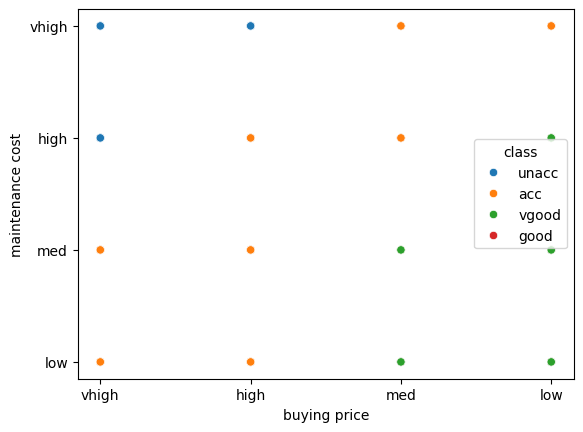

In [24]:
sns.scatterplot(x = df['buying price'], y = df['maintenance cost'], hue = df['class'])
plt.show()

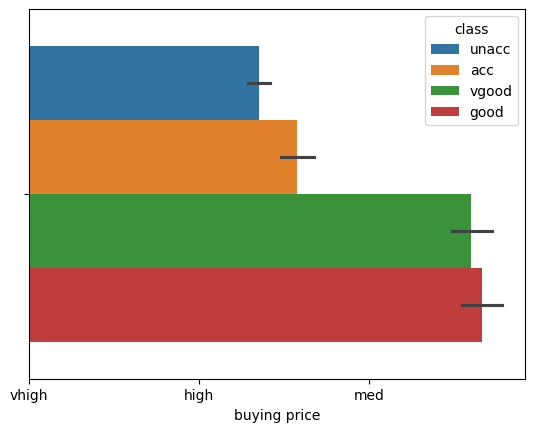

In [25]:
sns.barplot(x = df['buying price'], hue = df['class'])
plt.show()

In [26]:
X = df.drop('class', axis=1)
y = df['class']

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [29]:
X_train.shape

(1208, 6)

In [30]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
df.columns

Index(['buying price', 'maintenance cost', 'number of doors',
       'number of persons', 'lug_boot', 'safety', 'class'],
      dtype='object')

In [32]:
categorical_cols = ['buying price', 'maintenance cost','lug_boot', 'safety']
numerical_cols = ['number of doors','number of persons']

In [ ]:
ordinal_encoder = OrdinalEncoder(categories=[
    ['low','med','high','vhigh'], #buying price
    ['low','med','high','vhigh'], #maintenance cost
    ['small','med','big'], #lug_boot
    ['low','med','high'] # safety
])

preprocessor = ColumnTransformer(transformers=[
    ('transformation_name_doesnt_matter',ordinal_encoder,categorical_cols),
],  remainder='passthrough')

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [34]:
pd.DataFrame(X_test_transformed)

,0,1,2,3,4,5
0,3.0,1.0,2.0,1.0,4.0,4.0
1,1.0,0.0,2.0,2.0,5.0,5.0
2,1.0,0.0,0.0,2.0,4.0,2.0
3,3.0,1.0,1.0,0.0,2.0,2.0
4,3.0,1.0,2.0,2.0,5.0,4.0
...,...,...,...,...,...,...
514,0.0,1.0,2.0,2.0,3.0,4.0
515,1.0,2.0,0.0,2.0,4.0,5.0
516,1.0,3.0,2.0,0.0,3.0,2.0
517,1.0,0.0,2.0,2.0,2.0,4.0


In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
tree_model = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state=0)

In [38]:
tree_model.fit(X_train_transformed,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [39]:
y_pred = tree_model.predict(X_test_transformed)

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [41]:
print("Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: \n", classification_report(y_test, y_pred))

Score: 0.7861271676300579
Confusion Matrix: 
 [[ 62   0  59   0]
 [ 21   0   0   0]
 [ 10   0 346   0]
 [ 21   0   0   0]] 

Classification Report: 
               precision    recall  f1-score   support

         acc       0.54      0.51      0.53       121
        good       0.00      0.00      0.00        21
       unacc       0.85      0.97      0.91       356
       vgood       0.00      0.00      0.00        21

    accuracy                           0.79       519
   macro avg       0.35      0.37      0.36       519
weighted avg       0.71      0.79      0.75       519



C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[Text(0.3333333333333333, 0.875, 'number of persons <= 3.0\ngini = 0.451\nsamples = 1208\nvalue = [263, 48, 853, 44]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 409\nvalue = [0, 0, 409, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'safety <= 0.5\ngini = 0.576\nsamples = 799\nvalue = [263, 48, 444, 44]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 269\nvalue = [0, 0, 269, 0]'),
 Text(0.6666666666666666, 0.375, 'buying price <= 1.5\ngini = 0.63\nsamples = 530\nvalue = [263, 48, 175, 44]'),
 Text(0.5, 0.125, 'gini = 0.647\nsamples = 270\nvalue = [142, 48, 36, 44]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.498\nsamples = 260\nvalue = [121, 0, 139, 0]')]

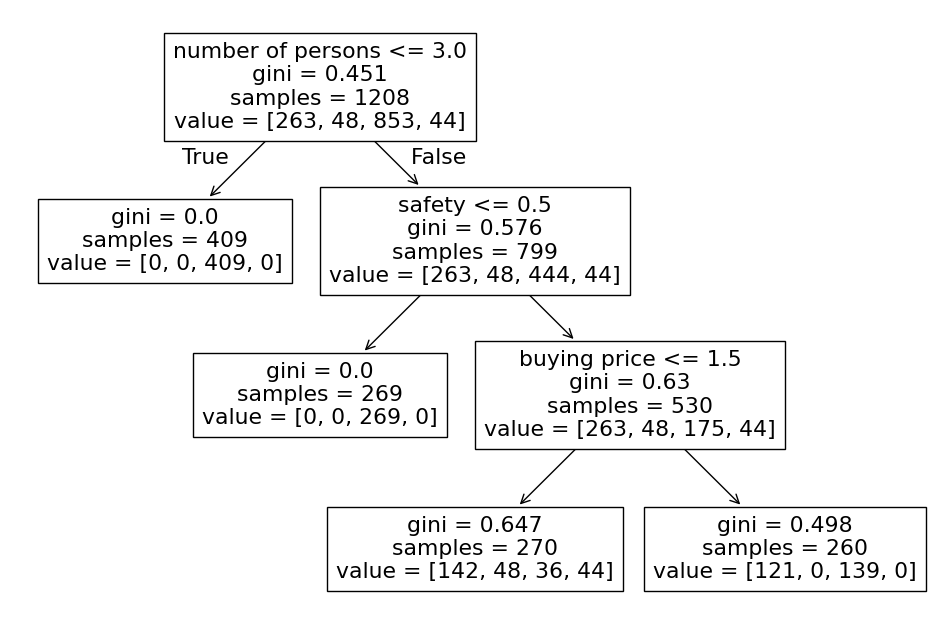

In [ ]:
plt.figure(figsize=(12,8))

column_name = categorical_cols + numerical_cols
from sklearn import  tree

tree.plot_tree(tree_model.fit(X_train_transformed,y_train), feature_names = column_name)

In [43]:
#  hyperparameter tunin

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter' : ['best','random'],
    'max_depth' : [1,2,3,4,5,15,None],
    'max_features' : ['sqrt','log2',None]
}

In [46]:
grid = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = param_grid, n_jobs=-1, cv = 5, scoring="accuracy")

In [47]:
import warnings
warnings.filterwarnings("ignore")

grid.fit(X_train_transformed,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [48]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [49]:
grid.best_score_

0.9702102122698125

In [50]:
y_pred = grid.predict(X_test_transformed)
print("Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: \n", classification_report(y_test, y_pred))

Score: 0.9730250481695568
Confusion Matrix: 
 [[119   0   1   1]
 [  3  18   0   0]
 [  9   0 347   0]
 [  0   0   0  21]] 

Classification Report: 
               precision    recall  f1-score   support

         acc       0.91      0.98      0.94       121
        good       1.00      0.86      0.92        21
       unacc       1.00      0.97      0.99       356
       vgood       0.95      1.00      0.98        21

    accuracy                           0.97       519
   macro avg       0.97      0.95      0.96       519
weighted avg       0.97      0.97      0.97       519



In [51]:
tree_model_new = DecisionTreeClassifier(criterion='entropy',max_depth=15, max_features=None, splitter='best')
tree_model_new.fit(X_train_transformed,y_train)
y_pred = tree_model_new.predict(X_test_transformed)
print("Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: \n", classification_report(y_test, y_pred))

Score: 0.9730250481695568
Confusion Matrix: 
 [[119   0   1   1]
 [  3  18   0   0]
 [  9   0 347   0]
 [  0   0   0  21]] 

Classification Report: 
               precision    recall  f1-score   support

         acc       0.91      0.98      0.94       121
        good       1.00      0.86      0.92        21
       unacc       1.00      0.97      0.99       356
       vgood       0.95      1.00      0.98        21

    accuracy                           0.97       519
   macro avg       0.97      0.95      0.96       519
weighted avg       0.97      0.97      0.97       519



[Text(0.6140202702702703, 0.9615384615384616, 'number of persons <= 3.0\nentropy = 1.192\nsamples = 1208\nvalue = [263, 48, 853, 44]'),
 Text(0.6005067567567568, 0.8846153846153846, 'entropy = 0.0\nsamples = 409\nvalue = [0, 0, 409, 0]'),
 Text(0.6072635135135136, 0.9230769230769231, 'True  '),
 Text(0.6275337837837838, 0.8846153846153846, 'safety <= 0.5\nentropy = 1.473\nsamples = 799\nvalue = [263, 48, 444, 44]'),
 Text(0.620777027027027, 0.9230769230769231, '  False'),
 Text(0.6140202702702703, 0.8076923076923077, 'entropy = 0.0\nsamples = 269\nvalue = [0, 0, 269, 0]'),
 Text(0.6410472972972973, 0.8076923076923077, 'buying price <= 1.5\nentropy = 1.641\nsamples = 530\nvalue = [263, 48, 175, 44]'),
 Text(0.40371621621621623, 0.7307692307692307, 'maintenance cost <= 1.5\nentropy = 1.745\nsamples = 270\nvalue = [142, 48, 36, 44]'),
 Text(0.19932432432432431, 0.6538461538461539, 'safety <= 1.5\nentropy = 1.805\nsamples = 134\nvalue = [43, 48, 8, 35]'),
 Text(0.08108108108108109, 0.57692

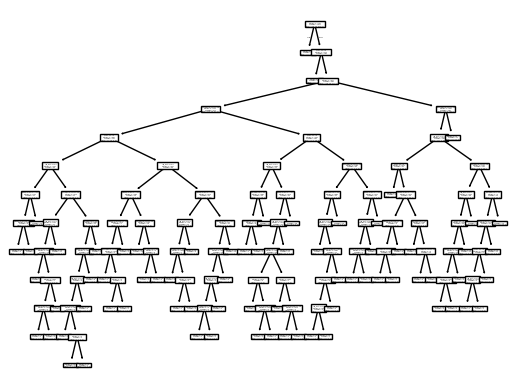

In [ ]:
tree.plot_tree(tree_model_new.fit(X_train_transformed,y_train), feature_names = column_name)

In [53]:
#  Pruning

In [54]:
df_new = pd.read_csv("11-Iris.csv")

In [55]:
df_new.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [56]:
X = df_new.drop(['Id','Species'],axis=1)
y = df_new['Species']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [58]:
tree_model = DecisionTreeClassifier()

In [59]:
tree_model.fit(X_train,y_train)

DecisionTreeClassifier()

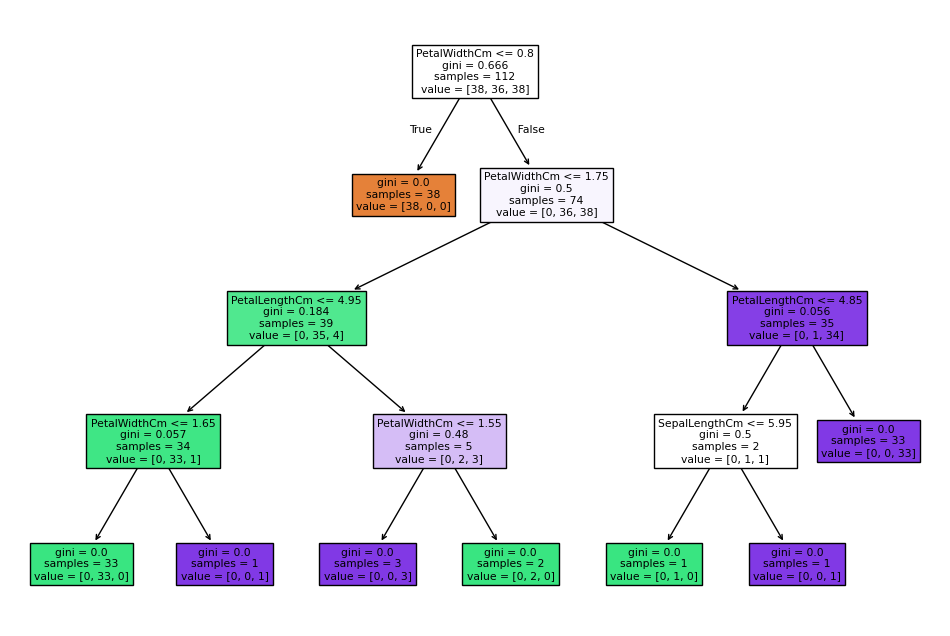

In [ ]:
plt.figure(figsize=(12,8))
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names = X_train.columns, filled= True)
plt.show()

In [61]:
y_pred = tree_model.predict(X_test)
print("Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: \n", classification_report(y_test, y_pred))

Score: 0.9736842105263158
Confusion Matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  1 11]] 

Classification Report: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.93      1.00      0.97        14
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



In [62]:
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train,y_train)
y_pred = tree_model.predict(X_test)
print("Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: \n", classification_report(y_test, y_pred))

Score: 0.9736842105263158
Confusion Matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  1 11]] 

Classification Report: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.93      1.00      0.97        14
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



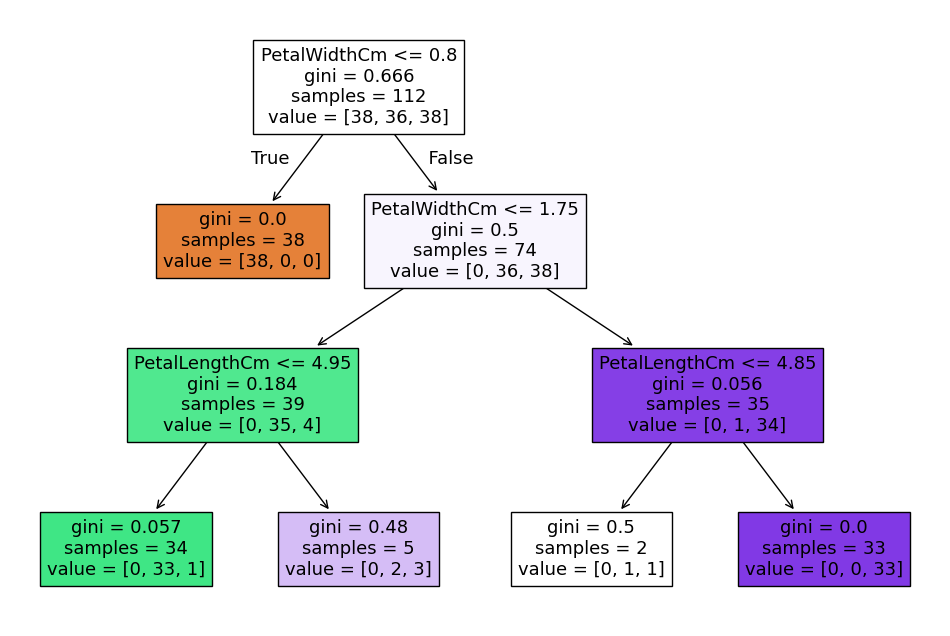

In [ ]:
plt.figure(figsize=(12,8))
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names = X_train.columns, filled= True)
plt.show()